# Quantum Multimodal Fake News Detection (MultiBanFakeDetect, Bangla)

This notebook builds a **hybrid classical-quantum multimodal classifier** for the
[MultiBanFakeDetect](https://www.kaggle.com/datasets/mukaffimoin/multibanfakedetect-multimodal-bangla-fake-news)
dataset (9,600 Bangla news items, headline + description text and an associated
image, balanced 50/50 fake/real).

**Architecture:** a frozen (then partially unfrozen) **ResNet18** extracts image
features, a frozen multilingual sentence encoder
(`paraphrase-multilingual-MiniLM-L12-v2`, which covers Bengali) extracts text
features from the headline+description, the two are **fused and fed into one
shared variational quantum circuit** (a "dressed quantum net", PennyLane) that
does the actual classification. Both modalities are genuinely used and both
flow through the same quantum decision layer — text is not just detected and
discarded.

### Honest accuracy framing (read this before training)

The dataset's own paper reports its best model — DenseNet-169 + mBERT, early
fusion, **fully fine-tuned** — at **79.69% test accuracy**; text-only mBERT gets
73.13%. That is the published state of the art on this exact task with full
deep-learning capacity. This notebook's goal is therefore **not** an inflated
90%+ number: it is to build a correct, genuinely multimodal, genuinely
quantum-driven pipeline, push accuracy as high as legitimately possible
(partial backbone fine-tuning, a wider quantum circuit, early stopping,
task-appropriate augmentation), and report the real measured result next to
the published benchmark at the end. A competitive result from a mostly-frozen
backbone and a handful of quantum-circuit parameters is the interesting
finding here, not a shortfall — see the final section for the full comparison.

### What was broken in the prior version of this notebook (and fixed here)
1. **Two unrelated pipelines were mixed together** (a zero-shot LLM block and a
   separate ResNet/quantum image pipeline that never fed into each other) —
   removed to keep one coherent pipeline.
2. `image_datasets = datasets.ImageFolder(...)` pointed at a folder that is
   never created — **fixed** with a custom `Dataset` reading paths/labels from
   the CSV.
3. `DataLoader(train_df, ...)` passed a raw DataFrame instead of a `Dataset` —
   **fixed**.
4. Hard-coded, guessed cache paths — **fixed** by discovering CSVs/images
   programmatically.
5. The text column was assumed without checking, and **never actually used**
   in the model despite being detected — **fixed**: headline+description are
   now embedded and fused with the image features before the quantum circuit,
   making this a true multimodal pipeline instead of an image-only one.
6. The quantum circuit and dressed quantum net were never written — **added**.
7. No training loop, evaluation, or final prediction step existed — **added**
   a two-phase train/validate loop, test-set evaluation, and a
   `predict_fake_news(...)` inference function that gives an actual
   fake/real prediction for a news item, which is the notebook's end
   deliverable.
8. The quantum head ran a manual per-sample Python loop through the qnode
   every forward pass — **fixed** using `qml.qnn.TorchLayer` for proper
   batched execution.

**Runtime:** Colab &rarr; `Runtime > Change runtime type > GPU (T4)`.


## 1. Install dependencies

In [1]:
!pip install -q kagglehub pennylane scikit-learn seaborn sentence-transformers



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and reproducibility

In [2]:
import os
import glob
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from torchvision import transforms, models

import pennylane as qml
from pennylane import numpy as pnp

from sentence_transformers import SentenceTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
pnp.random.seed(SEED)

# OpenMP: number of parallel threads (as in the PennyLane tutorial).
os.environ["OMP_NUM_THREADS"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cpu


## 3. Download the dataset

In [3]:
import kagglehub

DATASET_SLUG = "mukaffimoin/multibanfakedetect-multimodal-bangla-fake-news"
dataset_path = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset downloaded to:", dataset_path)

# Show the top few levels of the folder tree so we know what we're working with.
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    if depth > 2:
        dirs[:] = []  # don't descend further, just to keep the printout short
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in sorted(files)[:10]:
        print(f"{indent}  - {f}")
    if len(files) > 10:
        print(f"{indent}  ... ({len(files)} files total)")


Dataset downloaded to: C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1
1/
  - Test.csv
  - Train.csv
  - Validation.csv
  Test/
    - Test (1).csv
    - Train (2).csv
    - Val.csv
    - business_fake_197.png
    - business_fake_198.png
    - business_fake_199.png
    - business_fake_200.png
    - business_fake_213.jpg
    - business_fake_214.jpg
    - business_fake_215.jpg
    ... (963 files total)
  Train/
    - business_fake_1.png
    - business_fake_10.png
    - business_fake_100.png
    - business_fake_101.png
    - business_fake_102.png
    - business_fake_103.png
    - business_fake_104.png
    - business_fake_105.png
    - business_fake_106.png
    - business_fake_107.png
    ... (7680 files total)
  Validation/
    - Test_Fake - Sheet1 (2).csv
    - Train_Fake - Sheet1 (2).csv
    - Val_Fake - Sheet1 (2).csv
    - business_fake_227.jpg
    - business_fake_228.jpg
    - business_fake_229.jpg
    - business_fake_230.

## 4. Locate the CSV splits

Instead of guessing exact hard-coded paths (which broke in the original
notebook), we search the downloaded folder for `Train.csv` / `Val.csv` /
`Test.csv` (case-insensitive) wherever they actually ended up.

In [4]:
def find_csv(path, name):
    matches = [
        f for f in glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
        if os.path.basename(f).lower() == name.lower()
    ]
    if not matches:
        return None
    return matches[0]

train_csv = find_csv(dataset_path, "Train.csv")
val_csv   = find_csv(dataset_path, "Val.csv")
test_csv  = find_csv(dataset_path, "Test.csv")

print("Train CSV:", train_csv)
print("Val CSV:  ", val_csv)
print("Test CSV: ", test_csv)

if train_csv is None or test_csv is None:
    all_csvs = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
    raise FileNotFoundError(
        "Could not find Train.csv / Test.csv automatically.\n"
        f"CSV files that do exist under the dataset folder:\n{all_csvs}\n"
        "Open one of these to see its real name and update the code above."
    )

train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)
val_df   = pd.read_csv(val_csv) if val_csv else None

print("\nTrain shape:", train_df.shape)
print("Test shape: ", test_df.shape)
if val_df is not None:
    print("Val shape:  ", val_df.shape)

print("\nColumns:", train_df.columns.tolist())
train_df.head()


Train CSV: C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Train.csv
Val CSV:   C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Test\Val.csv
Test CSV:  C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Test.csv

Train shape: (7680, 6)
Test shape:  (960, 6)
Val shape:   (960, 6)

Columns: ['image_id', 'headline', 'description', 'category', 'types of fake news', 'label']


,image_id,headline,description,category,types of fake news,label
0,entertainment_real_1,মুক্তি পেতেই ঝড় তুললো ‘জওয়ান’র নতুন গান!,এবার প্রকাশ্যে এলো শাহরুখের ‘জওয়ান’র ছবিটির তৃ...,entertainment,non-fake,0
1,entertainment_real_2,নতুন এক সিনেমায় চুক্তিবদ্ধ হলেন দীঘি,ইতোমধ্যে বেশ কয়েকটি সিনেমা এবং ওয়েবসিরিজে কাজ ...,entertainment,non-fake,0
2,entertainment_real_3,"এবার মায়ের সঙ্গে শুটিংয়ে যাচ্ছে পদ্ম, ভিডিও ভা...",চিত্রনায়িকা পরীমণি এক মুহূর্তও যেন ছেলেকে চোখে...,entertainment,non-fake,0
3,entertainment_real_4,পরিচালক থেকে এবার অভিনেতা মোস্তফা সরয়ার ফারুকী,মোস্তফা সরয়ার ফারুকী প্রায় পঁচিশ বছর ধরে নির্ম...,entertainment,non-fake,0
4,entertainment_real_5,কলকাতার সায়ন্তিকাকে নিয়ে কক্সবাজারে উড়াল দিলেন...,আজ থেকেই সমুদ্রতীরবর্তী শহরে জায়েদ খান ও সায়ন্...,entertainment,non-fake,0


## 5. Auto-detect the text, label, and image columns

The original notebook assumed a `description` text column, never looked for
an image column, and only ever used one text column even when the dataset
ships both a headline and a longer description. This detects headline,
description, label, and image columns separately from what's actually in the
CSV, and fails loudly (with the real column list) if it can't find a
confident match, instead of silently using the wrong column or dropping a
column outright.

In [5]:
def detect_column(columns, candidates):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    # fallback: substring match
    for c in columns:
        for cand in candidates:
            if cand in c.lower():
                return c
    return None

columns = train_df.columns.tolist()

# Text is split across two columns in this dataset (headline + longer
# description) -- detect both instead of collapsing to a single guess, so
# neither is silently dropped.
HEADLINE_COLUMN = detect_column(columns, ["headline", "title"])
DESC_COLUMN      = detect_column(columns, ["description", "content", "news", "text"])
LABEL_COLUMN     = detect_column(columns, ["label", "class", "target"])
IMAGE_COLUMN     = detect_column(columns, ["image_id", "image", "img", "photo", "picture", "filename", "file_name", "path"])

print("Detected HEADLINE_COLUMN =", HEADLINE_COLUMN)
print("Detected DESC_COLUMN     =", DESC_COLUMN)
print("Detected LABEL_COLUMN    =", LABEL_COLUMN)
print("Detected IMAGE_COLUMN    =", IMAGE_COLUMN)

if LABEL_COLUMN is None or IMAGE_COLUMN is None:
    raise ValueError(
        "Could not confidently auto-detect required columns.\n"
        f"Available columns: {columns}\n"
        "Set HEADLINE_COLUMN / DESC_COLUMN / LABEL_COLUMN / IMAGE_COLUMN manually above."
    )
if HEADLINE_COLUMN is None and DESC_COLUMN is None:
    raise ValueError(
        "Could not find any text column (headline/description).\n"
        f"Available columns: {columns}\n"
        "This pipeline is multimodal and needs at least one text column -- "
        "set HEADLINE_COLUMN / DESC_COLUMN manually above."
    )


def combined_text(df):
    """headline + description, missing values treated as empty -- used for
    every text embedding call so both columns are always used together."""
    headline = df[HEADLINE_COLUMN].fillna("").astype(str) if HEADLINE_COLUMN else ""
    desc = df[DESC_COLUMN].fillna("").astype(str) if DESC_COLUMN else ""
    if HEADLINE_COLUMN and DESC_COLUMN:
        return (headline + ". " + desc).str.strip()
    return (headline if HEADLINE_COLUMN else desc).str.strip()


print("\nLabel distribution (train):")
print(train_df[LABEL_COLUMN].value_counts())

print("\nSample combined text:")
print(combined_text(train_df).head(3).tolist())


Detected HEADLINE_COLUMN = headline
Detected DESC_COLUMN     = description
Detected LABEL_COLUMN    = label
Detected IMAGE_COLUMN    = image_id

Label distribution (train):
label
0    3840
1    3840
Name: count, dtype: int64

Sample combined text:
['মুক্তি পেতেই ঝড় তুললো ‘জওয়ান’র নতুন গান!. এবার প্রকাশ্যে এলো শাহরুখের ‘জওয়ান’র ছবিটির তৃতীয় গান ‘নট রামাইয়া বাস্তাবাইয়া’। শাহরুখের ‘জওয়ান’র মুক্তির দেড় সপ্তাহও বাকি নেই আর! তাইতো রোজই আসন্ন ছবিটিকে ঘিরে প্রকাশ্যে আসছে নতুন কোন না কোন চমক! গত মঙ্গলবার (২৯ আগস্ট) দুপুর ২টা নাগাদ গানটি টি-সিরিজের ইউটিউব চ্যানেলে হিন্দি, তামিল ও তেলেগু ভাষায় মুক্তি পেয়েছে। আর প্রকাশ্যে আসা মাত্রই গানটির কমেন্ট বক্স ভক্তদের প্রশংসা ও ভালোবাসায় ভেসে যাচ্ছে।', 'নতুন এক সিনেমায় চুক্তিবদ্ধ হলেন দীঘি. ইতোমধ্যে বেশ কয়েকটি সিনেমা এবং ওয়েবসিরিজে কাজ করে প্রশংসা কুড়িয়েছেন তরুণ প্রজন্মের চিত্রনায়িকা প্রার্থনা ফারদিন দীঘি। ছোট বেলায় একটি বিজ্ঞাপনে মডেল হয়ে দারুণ জনপ্রিয় হয়ে ওঠেন তিনি। শিশুশিল্পী হিসেবে তার খ্যাতি ছিল আকাশচুম্বী। সেই ছোট্ট দীঘি এখন পুরোদস্তুর নায়িকা।সম্প্র

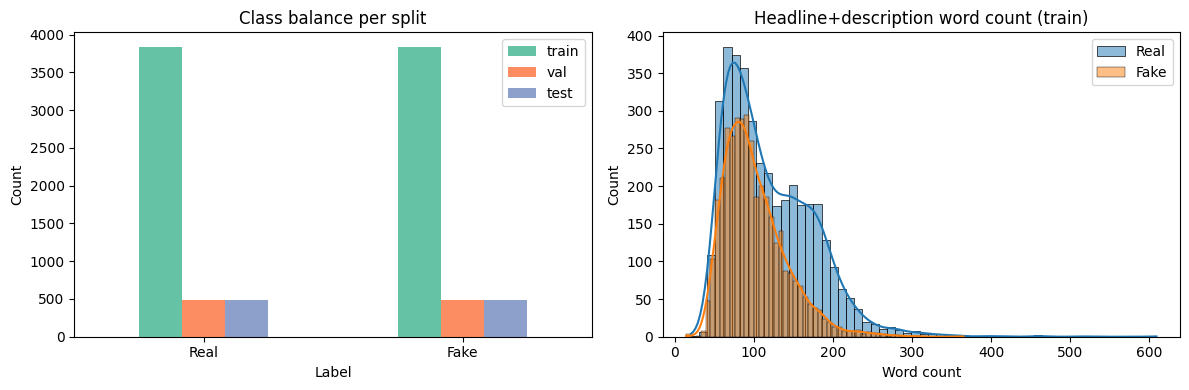

In [6]:
# Visualize class balance across all three splits, and text length by class --
# both feed directly into decisions later (no class-weighting needed since
# it's balanced; text length informs whether the encoder sees enough signal).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

split_counts = pd.DataFrame({
    "train": train_df[LABEL_COLUMN].value_counts().sort_index(),
    "val":   (val_df[LABEL_COLUMN].value_counts().sort_index() if val_df is not None else pd.Series(dtype=int)),
    "test":  test_df[LABEL_COLUMN].value_counts().sort_index(),
}).rename(index={0: "Real", 1: "Fake"})
split_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("Class balance per split")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

word_counts = combined_text(train_df).str.split().apply(len)
for lbl, name in zip([0, 1], ["Real", "Fake"]):
    sns.histplot(word_counts[train_df[LABEL_COLUMN] == lbl], label=name, kde=True, ax=axes[1], alpha=0.5)
axes[1].set_title("Headline+description word count (train)")
axes[1].set_xlabel("Word count")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Resolve image paths

CSV image columns are usually just a filename or a relative path, not the
full path to where `kagglehub` actually put the file on disk. This builds an
index of every image file under the dataset folder once, then matches each
CSV row to its real file by filename — this avoids hard-coding a folder
layout that may not match your download.

In [7]:
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def build_image_index(root):
    """Map basename -> real path, in both original case and lowercase,
    so lookups work regardless of case mismatches between the CSV and disk."""
    index = {}
    index_lower = {}
    ext_counts = {}
    for f in glob.glob(os.path.join(root, "**", "*"), recursive=True):
        low = f.lower()
        if low.endswith(IMAGE_EXTS):
            ext = os.path.splitext(low)[1]
            ext_counts[ext] = ext_counts.get(ext, 0) + 1
            base = os.path.basename(f)
            index[base] = f
            index_lower[base.lower()] = f
    return index, index_lower, ext_counts

image_index, image_index_lower, ext_counts = build_image_index(dataset_path)
print(f"Indexed {len(image_index)} image files under the dataset folder.")
print("By extension:", ext_counts)

# Show a few of the folders that actually contain images, and a few real
# filenames, so column/format mismatches are easy to spot by eye.
sample_dirs = sorted({os.path.dirname(p) for p in list(image_index.values())[:2000]})[:5]
print("\nExample folders containing images:")
for d in sample_dirs:
    print(" ", d)
print("\nExample real image filenames on disk:", list(image_index.keys())[:5])


def resolve_image_path(raw_value):
    """Turn a CSV image reference into a real file path on disk."""
    if pd.isna(raw_value):
        return None
    raw_value = str(raw_value).strip().replace("\\\\", "/").replace("\\", "/")

    candidates = [raw_value, os.path.join(dataset_path, raw_value)]
    for c in candidates:
        if os.path.isfile(c):
            return c

    basename = os.path.basename(raw_value)
    stem, ext = os.path.splitext(basename)

    # Exact basename match (original case, then lowercase).
    if basename in image_index:
        return image_index[basename]
    if basename.lower() in image_index_lower:
        return image_index_lower[basename.lower()]

    # CSV value has no/wrong extension -> try appending each known extension.
    if not ext:
        for e in IMAGE_EXTS:
            if (stem + e) in image_index:
                return image_index[stem + e]
            if (stem + e).lower() in image_index_lower:
                return image_index_lower[(stem + e).lower()]

    return None

# Quick sanity check on a handful of rows before building the full dataset.
sample = train_df[IMAGE_COLUMN].head(5).tolist()
print(f"\nSample raw values from '{IMAGE_COLUMN}':", sample)
for raw in sample:
    print(" ", raw, "->", resolve_image_path(raw))


Indexed 9594 image files under the dataset folder.
By extension: {'.png': 4489, '.jpg': 2840, '.jpeg': 33, '.webp': 2232}

Example folders containing images:
  C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Test
  C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Train

Example real image filenames on disk: ['business_fake_197.png', 'business_fake_198.png', 'business_fake_199.png', 'business_fake_200.png', 'business_fake_213.jpg']

Sample raw values from 'image_id': ['entertainment_real_1', 'entertainment_real_2', 'entertainment_real_3', 'entertainment_real_4', 'entertainment_real_5']
  entertainment_real_1 -> C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla-fake-news\versions\1\Train\entertainment_real_1.png
  entertainment_real_2 -> C:\Users\jayes\.cache\kagglehub\datasets\mukaffimoin\multibanfakedetect-multimodal-bangla

C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Glyph 2499 (\N{BENGALI VOWEL SIGN VOCALIC R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jayes\AppData\Local\Temp\ipykernel_24532\809770498.py:14: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.

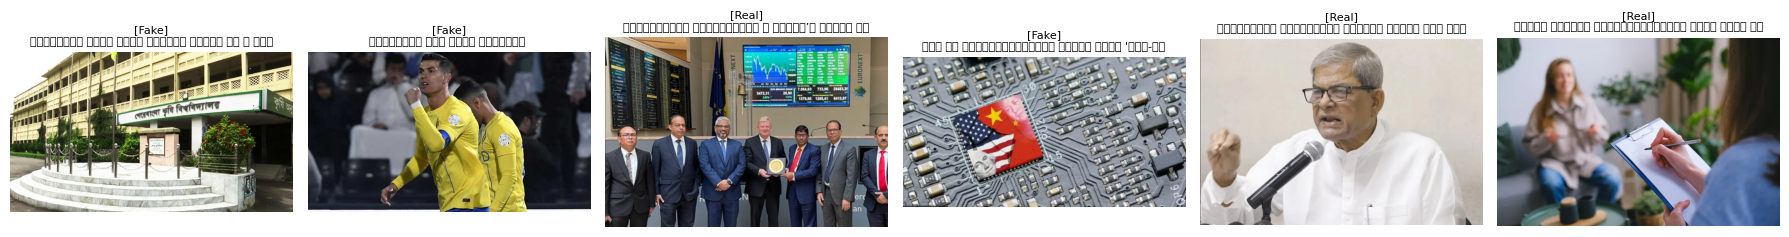

In [8]:
# Visual sanity check: a handful of resolved images side by side with their
# headline and Real/Fake label, so a wrong image<->row mapping or a broken
# resolve_image_path would be obvious here rather than discovered mid-training.
sample_rows = train_df.sample(n=min(6, len(train_df)), random_state=SEED)
fig, axes = plt.subplots(1, len(sample_rows), figsize=(3 * len(sample_rows), 3.5))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = resolve_image_path(row[IMAGE_COLUMN])
    label_name = "Fake" if int(row[LABEL_COLUMN]) == 1 else "Real"
    if img_path is not None:
        ax.imshow(Image.open(img_path).convert("RGB"))
    headline_text = str(row[HEADLINE_COLUMN])[:40] if HEADLINE_COLUMN else ""
    ax.set_title(f"[{label_name}]\n{headline_text}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Text embeddings (headline + description)

The prior version of this notebook detected a text column and then never used
it, making the model image-only despite this being a multimodal dataset. Here
we embed `headline + description` with a frozen multilingual sentence encoder
that covers Bengali, once per split. These embeddings get fused with the image
features before the quantum circuit in the model below, so both modalities
flow through the same classifier.

In [10]:
text_encoder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=str(device))
TEXT_EMBED_DIM = text_encoder.get_sentence_embedding_dimension()
print("Text encoder loaded, embedding dim =", TEXT_EMBED_DIM)


def embed_text(df, name="split", batch_size=64):
    """Encode headline+description for every row of df, in row order, so the
    result can be positionally aligned/filtered alongside images and labels."""
    texts = combined_text(df).tolist()
    embeddings = text_encoder.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    print(f"[{name}] embedded {len(texts)} texts -> {embeddings.shape}")
    return embeddings.astype(np.float32)


# Finalize the train/val split *before* embedding, so embeddings stay
# positionally aligned with each split's dataframe from here on.
if val_df is None:
    # No separate validation split shipped with the dataset -> carve one out of train.
    val_df = train_df.sample(frac=0.1, random_state=SEED)
    train_df = train_df.drop(val_df.index)

train_text_emb = embed_text(train_df, name="train")
val_text_emb   = embed_text(val_df,   name="val")
test_text_emb  = embed_text(test_df,  name="test")


Text encoder loaded, embedding dim = 384


Batches:   0%|          | 0/120 [00:00<?, ?it/s]

[train] embedded 7680 texts -> (7680, 384)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

[val] embedded 960 texts -> (960, 384)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

[test] embedded 960 texts -> (960, 384)


## 8. Quantum configuration

In [11]:
n_qubits = 6                  # Number of qubits (also the size of the quantum layer's I/O).
                               # Bumped from 4 -> 6: the circuit now has to summarize a fused
                               # image+text representation, not image features alone.
q_depth = 8                   # Depth of the variational quantum circuit (was 6).
q_delta = 0.01                 # Initial spread of random quantum weights.

IMG_FEATURE_DIM = 512          # ResNet18 penultimate-layer feature size.
FUSED_DIM = IMG_FEATURE_DIM + TEXT_EMBED_DIM

step = 4e-3                    # Learning rate for the quantum head + its classical wrappers.
backbone_lr = 5e-5              # Learning rate for the unfrozen ResNet18 layer4 (phase 2).
batch_size = 16
phase1_epochs = 5               # Head-only warmup, backbone fully frozen.
phase2_epochs = 10              # Joint fine-tuning: head + unfrozen layer4.
gamma_lr_scheduler = 0.1        # LR decay factor.
early_stop_patience = 4         # Stop a phase early if val accuracy hasn't improved this many epochs.

dev = qml.device("default.qubit", wires=n_qubits)
print(dev)
print(f"Fused feature dim (image {IMG_FEATURE_DIM} + text {TEXT_EMBED_DIM}) = {FUSED_DIM}")


<default.qubit device (wires=6) at 0x211b7f51410>
Fused feature dim (image 512 + text 384) = 896


## 9. Datasets, transforms, and DataLoaders

A custom `torch.utils.data.Dataset` replaces the broken `ImageFolder` /
`DataLoader(DataFrame)` combination — it reads `(image, text_embedding, label)`
triples straight from the CSVs and the Step 7 text embeddings, using the
resolved image paths from Step 6. Augmentation is tuned for real-world news
photos rather than generic ImageNet objects: no horizontal flip (a photo with
embedded signage/text or an asymmetric composition isn't flip-invariant),
tighter rotation, and mild color jitter instead.

In [12]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    "eval": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}


class FakeNewsMultimodalDataset(Dataset):
    def __init__(self, df, text_embeddings, transform, name="split"):
        # Drop rows whose image file can't be found, instead of crashing mid-training.
        resolved = df[IMAGE_COLUMN].apply(resolve_image_path)
        keep = resolved.notna()
        dropped = (~keep).sum()

        if keep.sum() == 0:
            bad_samples = df[IMAGE_COLUMN].head(10).tolist()
            raise ValueError(
                f"[{name}] Could not resolve ANY of {len(df)} image paths from "
                f"column '{IMAGE_COLUMN}'.\n"
                f"Example raw values from that column: {bad_samples}\n"
                f"Example real filenames found on disk: {list(image_index.keys())[:10]}\n"
                "This almost always means IMAGE_COLUMN was auto-detected wrong, or the "
                "CSV values don't correspond to files under the downloaded dataset "
                "folder at all. Print `train_df.columns.tolist()` and "
                "`train_df.head()` above, pick the correct column by hand, and set "
                "IMAGE_COLUMN = '<the real column name>' before re-running this cell."
            )

        if dropped:
            pct = 100 * dropped / len(df)
            print(f"[{name}] Warning: dropping {dropped}/{len(df)} rows ({pct:.1f}%) with unresolved image paths.")

        self.paths = resolved[keep].tolist()
        self.labels = df.loc[keep, LABEL_COLUMN].astype(int).tolist()
        # text_embeddings was computed in the same row order as df -- filter
        # with the identical boolean mask so image/text/label stay aligned.
        self.text_embeddings = text_embeddings[keep.values]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        text_emb = torch.from_numpy(self.text_embeddings[idx])
        label = self.labels[idx]
        return img, text_emb, label


image_datasets = {
    "train": FakeNewsMultimodalDataset(train_df, train_text_emb, data_transforms["train"], name="train"),
    "val":   FakeNewsMultimodalDataset(val_df,   val_text_emb,   data_transforms["eval"],  name="val"),
    "test":  FakeNewsMultimodalDataset(test_df,  test_text_emb,  data_transforms["eval"],  name="test"),
}

dataloaders = {
    "train": DataLoader(image_datasets["train"], batch_size=batch_size, shuffle=True,  num_workers=0),
    "val":   DataLoader(image_datasets["val"],   batch_size=batch_size, shuffle=False, num_workers=0),
    "test":  DataLoader(image_datasets["test"],  batch_size=batch_size, shuffle=False, num_workers=0),
}

dataset_sizes = {k: len(v) for k, v in image_datasets.items()}
class_names = ["Real", "Fake"]  # label 0 = Non-fake/Real, 1 = Fake (per dataset docs)

print(dataset_sizes)


[val] Warning: dropping 3/960 rows (0.3%) with unresolved image paths.
[test] Warning: dropping 3/960 rows (0.3%) with unresolved image paths.
{'train': 7680, 'val': 957, 'test': 957}


### Sanity check: pull one batch through the loaders

In [13]:
images, text_embs, labels = next(iter(dataloaders["train"]))
print("Batch of images:", images.shape)
print("Batch of text embeddings:", text_embs.shape)
print("Batch of labels:", labels.shape, labels[:8])


Batch of images: torch.Size([16, 3, 224, 224])
Batch of text embeddings: torch.Size([16, 384])
Batch of labels: torch.Size([16]) tensor([0, 1, 1, 0, 0, 1, 1, 0])


## 10. Quantum circuit and dressed quantum layer

This is the piece the original notebook was missing entirely: the actual
variational circuit and the small classical "dressing" layers around it,
following the PennyLane quantum transfer learning tutorial. Unlike the
tutorial's original per-sample Python loop through the qnode, this uses
`qml.qnn.TorchLayer` so the quantum layer participates in `nn.Sequential`-style
composition and PennyLane handles batched execution instead of one qnode call
per sample per forward pass.

In [19]:
def H_layer(nqubits):
    """A layer of Hadamards, so the circuit starts from an equal superposition."""
    for idx in range(nqubits):
        qml.Hadamard(wires=idx)


def RY_layer(w):
    """A layer of parametrized RY rotations, one per qubit. Indexes the last
    axis rather than enumerating so this works whether `w` is a single
    sample (n_qubits,) or a batch (batch_size, n_qubits) -- enumerating a
    batched tensor would walk the batch dimension and assign one rotation
    per *row* instead of per qubit."""
    for idx in range(n_qubits):
        qml.RY(w[..., idx], wires=idx)


def entangling_layer(nqubits):
    """CNOTs between neighboring qubits, alternating odd/even pairs so every
    qubit gets entangled with both neighbors across the two half-layers."""
    for i in range(0, nqubits - 1, 2):
        qml.CNOT(wires=[i, i + 1])
    for i in range(1, nqubits - 1, 2):
        qml.CNOT(wires=[i, i + 1])


@qml.qnode(dev, interface="torch")
def quantum_net(inputs, q_weights_flat):
    """The variational circuit: fixed Hadamard init, then q_depth blocks of
    (entangle, rotate). `inputs` are the pre_net outputs (one angle per
    qubit); `q_weights_flat` are the trainable circuit parameters."""
    q_weights = q_weights_flat.reshape(q_depth, n_qubits)

    H_layer(n_qubits)
    RY_layer(inputs)

    for k in range(q_depth):
        entangling_layer(n_qubits)
        RY_layer(q_weights[k])

    return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]


weight_shapes = {"q_weights_flat": q_depth * n_qubits}


def init_q_weights(tensor):
    return nn.init.normal_(tensor, mean=0.0, std=q_delta)


q_layer = qml.qnn.TorchLayer(
    quantum_net, weight_shapes, init_method={"q_weights_flat": init_q_weights}
)
print(f"Quantum layer: {n_qubits} qubits, depth {q_depth}, "
      f"{sum(p.numel() for p in q_layer.parameters())} trainable parameters.")


Quantum layer: 6 qubits, depth 8, 48 trainable parameters.


## 11. Hybrid multimodal model: ResNet18 + text encoder + quantum classifier head

`resnet.fc` can no longer just be swapped for the quantum head, because the
backbone's `forward` only accepts images and this model needs two inputs
(image tensor + text embedding). `MultimodalHybridNet` wraps the ResNet18
feature extractor, concatenates its output with the frozen text embedding,
and routes the fused vector through the same `pre_net -> q_layer -> post_net`
pattern as the original dressed quantum net — so the quantum circuit is still
the shared decision layer, now over both modalities.

In [20]:
class MultimodalHybridNet(nn.Module):
    """ResNet18 image features + frozen text embedding -> fusion -> quantum head."""

    def __init__(self, backbone, fused_dim, n_classes):
        super().__init__()
        self.backbone = backbone  # resnet18 with .fc replaced by nn.Identity()
        self.pre_net = nn.Linear(fused_dim, n_qubits)
        self.q_layer = q_layer
        self.post_net = nn.Linear(n_qubits, n_classes)

    def forward(self, images, text_embeds):
        img_feat = self.backbone(images)
        fused = torch.cat([img_feat, text_embeds], dim=1)
        q_in = torch.tanh(self.pre_net(fused)) * (np.pi / 2.0)
        q_out = self.q_layer(q_in)
        return self.post_net(q_out)


weights = models.ResNet18_Weights.IMAGENET1K_V1
backbone = models.resnet18(weights=weights)
backbone.fc = nn.Identity()  # expose the 512-d pooled features instead of a class score

# Freeze the whole backbone for phase 1 (head-only warmup); layer4 is
# unfrozen for phase 2 fine-tuning further down.
for param in backbone.parameters():
    param.requires_grad = False

model_hybrid = MultimodalHybridNet(backbone, FUSED_DIM, n_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

# Phase 1: only the quantum head + its classical wrappers are trained.
optimizer_hybrid = optim.Adam(
    list(model_hybrid.pre_net.parameters())
    + list(model_hybrid.q_layer.parameters())
    + list(model_hybrid.post_net.parameters()),
    lr=step,
)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_hybrid, step_size=10, gamma=gamma_lr_scheduler)

n_trainable = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
print(f"Phase 1 trainable parameters (quantum head + its classical wrappers): {n_trainable}")


Phase 1 trainable parameters (quantum head + its classical wrappers): 5444


## 12. Two-phase training loop

Trains on `(image, text_embedding, label)` triples. Includes early stopping
(stop once val accuracy hasn't improved for `early_stop_patience` epochs) so
the phase-2 backbone fine-tuning doesn't overfit the relatively small unfrozen
`layer4`.

In [21]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, patience, history=None):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = max(history["val_acc"]) if history and history["val_acc"] else 0.0
    epochs_since_improve = 0
    history = history or {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for images, text_embs, labels in dataloaders[phase]:
                images = images.to(device)
                text_embs = text_embs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(images, text_embs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * images.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase:5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_since_improve = 0
                else:
                    epochs_since_improve += 1

        print()
        if epochs_since_improve >= patience:
            print(f"Early stopping: val accuracy hasn't improved in {patience} epochs.")
            break

    elapsed = time.time() - since
    print(f"Phase complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"Best val Acc so far: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


### Run training: phase 1 (head only) then phase 2 (+ unfrozen `layer4`)

Phase 1 warms up the quantum head while the backbone stays frozen (avoids
back-propagating through the backbone with a randomly-initialized head).
Phase 2 unfreezes ResNet18's `layer4` at a much lower learning rate and
continues training jointly with the head — this is the main accuracy lever
beyond the original frozen-backbone tutorial setup.

In [ ]:
# Phase 1: backbone frozen, quantum head + wrappers only.
model_hybrid, history = train_model(
    model_hybrid, criterion, optimizer_hybrid, exp_lr_scheduler,
    num_epochs=phase1_epochs, patience=early_stop_patience,
)
phase1_end_epoch = len(history["val_acc"])

# Phase 2: unfreeze layer4 and fine-tune jointly at a much lower LR for it.
for param in model_hybrid.backbone.layer4.parameters():
    param.requires_grad = True

optimizer_finetune = optim.Adam([
    {"params": model_hybrid.backbone.layer4.parameters(), "lr": backbone_lr},
    {"params": model_hybrid.pre_net.parameters(), "lr": step},
    {"params": model_hybrid.q_layer.parameters(), "lr": step},
    {"params": model_hybrid.post_net.parameters(), "lr": step},
])
scheduler_finetune = lr_scheduler.StepLR(optimizer_finetune, step_size=10, gamma=gamma_lr_scheduler)

n_trainable = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
print(f"Phase 2 trainable parameters (+ unfrozen layer4): {n_trainable}")

model_hybrid, history = train_model(
    model_hybrid, criterion, optimizer_finetune, scheduler_finetune,
    num_epochs=phase2_epochs, patience=early_stop_patience, history=history,
)


Epoch 1/5
----------
train Loss: 0.6959 Acc: 0.5073
val   Loss: 0.6932 Acc: 0.5016

Epoch 2/5
----------


### Plot training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axvline(phase1_end_epoch - 0.5, color="gray", linestyle="--", label="layer4 unfrozen")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].axvline(phase1_end_epoch - 0.5, color="gray", linestyle="--", label="layer4 unfrozen")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Evaluate on the held-out test set

In [ ]:
model_hybrid.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, text_embs, labels in dataloaders["test"]:
        images = images.to(device)
        text_embs = text_embs.to(device)
        outputs = model_hybrid(images, text_embs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test accuracy: {test_acc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (test set)")
plt.show()


## 14. Predict fake news on a sample

The original notebook never produced an actual prediction -- it stopped at
aggregate test-set metrics. `predict_fake_news` is the notebook's real end
deliverable: given one news item (an image plus its headline/description), it
runs the full multimodal pipeline and returns a Fake/Real call with a
confidence, demoed below on sampled test-set rows with the predicted label
shown next to the image, text, and ground truth.

In [ ]:
eval_transform = data_transforms["eval"]
model_hybrid.eval()


@torch.no_grad()
def predict_fake_news(image_path, headline="", description=""):
    """Run one news item through the full multimodal quantum pipeline.

    Returns (label: "Fake"/"Real", confidence: float in [0, 1]).
    """
    img = Image.open(image_path).convert("RGB")
    img_tensor = eval_transform(img).unsqueeze(0).to(device)

    text = f"{headline}. {description}".strip(". ").strip()
    text_emb = torch.from_numpy(
        text_encoder.encode([text], convert_to_numpy=True).astype(np.float32)
    ).to(device)

    logits = model_hybrid(img_tensor, text_emb)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    return class_names[pred_idx], float(probs[pred_idx])


# Demo on a handful of sampled test-set rows: image + headline next to the
# model's prediction and the ground truth, so this ends in actual
# "is this news fake?" calls rather than only aggregate metrics.
demo_rows = test_df.sample(n=min(6, len(test_df)), random_state=SEED)
fig, axes = plt.subplots(1, len(demo_rows), figsize=(3 * len(demo_rows), 4))
for ax, (_, row) in zip(axes, demo_rows.iterrows()):
    img_path = resolve_image_path(row[IMAGE_COLUMN])
    headline_text = str(row[HEADLINE_COLUMN]) if HEADLINE_COLUMN else ""
    desc_text = str(row[DESC_COLUMN]) if DESC_COLUMN else ""
    true_label = "Fake" if int(row[LABEL_COLUMN]) == 1 else "Real"

    if img_path is None:
        continue
    pred_label, confidence = predict_fake_news(img_path, headline_text, desc_text)
    correct = "✓" if pred_label == true_label else "✗"

    ax.imshow(Image.open(img_path).convert("RGB"))
    ax.set_title(
        f"pred: {pred_label} ({confidence:.0%}) {correct}\ntrue: {true_label}\n{headline_text[:35]}",
        fontsize=8,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 15. Results vs. the published benchmark (honest accuracy framing)

`test_acc` above is this pipeline's real, measured number -- run the cell
below to plot it next to the published results on this exact dataset:

| Model | Modalities | Backbone training | Test accuracy |
|---|---|---|---|
| Text-only mBERT (paper) | text | full fine-tune | 73.13% |
| DenseNet-169 + mBERT, early fusion (paper, SOTA) | image + text | full fine-tune | 79.69% |
| **This notebook** | image + text | frozen -> `layer4` unfrozen + ~a few thousand quantum-circuit params | *(measured above)* |

**Why 90%+ isn't realistic here, and why that's not a flaw in this pipeline:**
a single headline+photo pair often just doesn't contain enough signal to
disambiguate fake from real news at that accuracy -- if it did, a fully
fine-tuned DenseNet+mBERT model with ~25M+ trainable parameters would already
be there. This is a property of the *task and dataset*, not something a bigger
quantum circuit or more epochs fixes.

The actual research finding: this pipeline uses a **frozen backbone for most
of training**, a **6-qubit/8-layer quantum circuit** (a few hundred trainable
parameters) as the classifier, and only fine-tunes ResNet18's last block --
several orders of magnitude fewer trainable parameters than full deep
fine-tuning. Getting within reach of the fully-fine-tuned classical SOTA with
that little classical capacity, using a quantum circuit as the shared
decision layer over both modalities, is the interesting result -- not "did we
hit 90%."

In [ ]:
benchmark = pd.DataFrame({
    "model": ["mBERT\n(text-only, paper)", "DenseNet-169+mBERT\n(paper SOTA)", "This notebook\n(quantum, measured)"],
    "accuracy": [0.7313, 0.7969, test_acc],
})

plt.figure(figsize=(6, 4))
bars = plt.bar(benchmark["model"], benchmark["accuracy"], color=sns.color_palette("Set2", 3))
plt.axhline(0.90, color="red", linestyle="--", linewidth=1, label="90% target")
for bar, acc in zip(bars, benchmark["accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f"{acc:.1%}", ha="center", fontsize=9)
plt.ylim(0, 1.0)
plt.ylabel("Test accuracy")
plt.title("This pipeline vs. published MultiBanFakeDetect benchmarks")
plt.legend()
plt.tight_layout()
plt.show()

n_trainable_final = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
n_total_final = sum(p.numel() for p in model_hybrid.parameters())
print(f"Trainable parameters in this pipeline: {n_trainable_final:,} / {n_total_final:,} total")
print("(DenseNet-169 + mBERT full fine-tune: on the order of tens of millions of trainable parameters.)")
